In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

class GeneradorSegmentacionTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        self.num_clases = 19
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y)).astype(np.int32)
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            mask_one_hot = tf.one_hot(parche_Y, depth=self.num_clases, dtype=tf.float32).numpy()
            
            batch_X.append(parche_X)
            batch_Y.append(mask_one_hot)
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), 
                    np.zeros((1, 48, 48, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

carpeta_dataset = r"D:\TFG\dataset_parches_50x50"
todos_los_X_total = sorted([f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')])

np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)
archivos_prueba = todos_los_X_total[:150000]

archivos_train, archivos_val = train_test_split(archivos_prueba, test_size=0.2, random_state=42)

generador_train = GeneradorSegmentacionTFG(carpeta_dataset, archivos_train, batch_size=64, shuffle=True)
generador_val = GeneradorSegmentacionTFG(carpeta_dataset, archivos_val, batch_size=64, shuffle=False)

def build_unet_autoencoder(input_shape, num_classes):
    entradas = layers.Input(shape=input_shape)
    
    init = 'he_normal'
    reg = tf.keras.regularizers.l2(1e-6)
    
    x = layers.Normalization(axis=-1)(entradas)
    
    # ENCODER
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(x)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Cuello de botella
    bottleneck = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p2)
    bottleneck = layers.BatchNormalization()(bottleneck)
    bottleneck = layers.Activation('gelu')(bottleneck)
    
    # DECODER
    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(bottleneck)
    merge3 = layers.concatenate([u3, c2]) 
    c3 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('gelu')(c3)
    
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(c3)
    merge4 = layers.concatenate([u4, c1]) 
    c4 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('gelu')(c4)
    
    salidas = layers.Conv2D(num_classes, (1, 1), activation='softmax', kernel_initializer=init)(c4)
    
    return models.Model(inputs=entradas, outputs=salidas)

model = build_unet_autoencoder((48, 48, 4), 19)

def dice_loss_multiclass(y_true, y_pred):
    y_pred = tf.nn.softmax(y_pred, axis=-1)
    
    smooth = 1e-5
    
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    area_true = tf.reduce_sum(y_true, axis=[1, 2])
    area_pred = tf.reduce_sum(y_pred, axis=[1, 2])
    
    dice_coef = (2.0 * intersection + smooth) / (area_true + area_pred + smooth)
    
    return 1.0 - tf.reduce_mean(dice_coef)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipvalue=0.5),
    loss=dice_loss_multiclass, 
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=40,
    callbacks=mis_callbacks
)

Epoch 1/40
1875/1875 [==============================] - 2062s 1s/step - loss: 0.9930 - accuracy: 0.3841 - val_loss: 0.9927 - val_accuracy: 0.3688 - lr: 0.0010
Epoch 2/40
1875/1875 [==============================] - 2041s 1s/step - loss: 0.9927 - accuracy: 0.3817 - val_loss: 0.9927 - val_accuracy: 0.4131 - lr: 0.0010
Epoch 3/40
1875/1875 [==============================] - 1908s 1s/step - loss: 0.9926 - accuracy: 0.3846 - val_loss: 0.9926 - val_accuracy: 0.3616 - lr: 0.0010
Epoch 4/40
1875/1875 [==============================] - 3137s 2s/step - loss: 0.9926 - accuracy: 0.3843 - val_loss: 0.9928 - val_accuracy: 0.3666 - lr: 0.0010
Epoch 5/40
1875/1875 [==============================] - 2664s 1s/step - loss: 0.9926 - accuracy: 0.3785 - val_loss: 0.9928 - val_accuracy: 0.3544 - lr: 0.0010
Epoch 6/40
1875/1875 [==============================] - ETA: 0s - loss: 0.9926 - accuracy: 0.3864
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1875/1875 [====================

KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

class GeneradorSegmentacionTFG(Sequence):
    def __init__(self, carpeta_parches, lista_archivos, batch_size=64, shuffle=True):
        self.carpeta = carpeta_parches
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.archivos_X = lista_archivos
        # Cambiado a 20 porque la clase '19' requiere que el vector tenga longitud 20 (índices 0 al 19)
        self.num_clases = 20
        self.indices = np.arange(len(self.archivos_X))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.archivos_X) / self.batch_size))

    def __getitem__(self, index):
        indices_batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_X = []
        batch_Y = []
        
        for idx in indices_batch:
            nom_X = self.archivos_X[idx]
            nom_Y = nom_X.replace('_X.npy', '_Y.npy')
            
            parche_X = np.load(os.path.join(self.carpeta, nom_X)).astype(np.float32)
            parche_Y = np.load(os.path.join(self.carpeta, nom_Y)).astype(np.int32)
            
            if parche_X.shape[0] == 4:
                parche_X = np.transpose(parche_X, (1, 2, 0))
            
            parche_X = parche_X[:48, :48, :]
            parche_Y = parche_Y[:48, :48]
            
            # Si se coló algún código corrupto fuera del rango [0, 19], lo forzamos a ser 19
            parche_Y = np.where((parche_Y >= 0) & (parche_Y <= 19), parche_Y, 19)
            
            mask_one_hot = tf.one_hot(parche_Y, depth=self.num_clases, dtype=tf.float32).numpy()
            
            batch_X.append(parche_X)
            batch_Y.append(mask_one_hot)
            
        if len(batch_X) == 0:
            return (np.zeros((1, 48, 48, 4), dtype=np.float32), 
                    np.zeros((1, 48, 48, self.num_clases), dtype=np.float32))
            
        return np.array(batch_X), np.array(batch_Y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# --- 1. FILTRADO INTELIGENTE PREVIO DEL DATASET (EVITAR PARCHES VACÍOS) ---
carpeta_dataset = r"D:\TFG\dataset_parches_50x50"

print("Paso 1: Escaneando nombres de archivos en el disco...", flush=True)
# os.listdir solo lee texto (los nombres), esto tarda menos de 2 segundos para 1 millón
todos_los_X_total = [f for f in os.listdir(carpeta_dataset) if f.endswith('_X.npy')]

# Mezclamos todos los nombres aleatoriamente
np.random.seed(4215) 
np.random.shuffle(todos_los_X_total)

print("Paso 2: Buscando parches útiles reales hasta completar tu cupo...", flush=True)
archivos_prueba = []
cupo_deseado = 50000  # <--- Cambia aquí el número de datos que quieras entrenar

for nom_X in todos_los_X_total:
    if len(archivos_prueba) >= cupo_deseado:
        break  # Nos detenemos inmediatamente cuando ya tenemos los 5,000 limpios
        
    nom_Y = nom_X.replace('_X.npy', '_Y.npy')
    try:
        # Cargamos solo si el archivo existe
        parche_y = np.load(os.path.join(carpeta_dataset, nom_Y))
        conteos = np.bincount(parche_y.ravel(), minlength=20)
        
        # Si NO está dominado por el vacío (19), directo a la lista de entrenamiento
        if np.argmax(conteos[:20]) != 19:
            archivos_prueba.append(nom_X)
    except Exception:
        continue

print(f"¡Listo! Dataset seleccionado con {len(archivos_prueba):,} parches de alta calidad.")

# Ahora sí, hacemos el split sobre los 5,000 aislados
archivos_train, archivos_val = train_test_split(archivos_prueba, test_size=0.2, random_state=42)

generador_train = GeneradorSegmentacionTFG(carpeta_dataset, archivos_train, batch_size=128, shuffle=True)
generador_val = GeneradorSegmentacionTFG(carpeta_dataset, archivos_val, batch_size=128, shuffle=False)

# --- 2. CONFIGURACIÓN DE LA ARQUITECTURA DE LA U-NET (20 CLASES DE SALIDA) ---
def build_unet_autoencoder(input_shape, num_classes):
    entradas = layers.Input(shape=input_shape)
    init = 'he_normal'
    reg = tf.keras.regularizers.l2(1e-6)
    
    x = layers.Normalization(axis=-1)(entradas)
    
    # ENCODER
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(x)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    c1 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('gelu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    c2 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('gelu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # BOTTLENECK
    bottleneck = layers.Conv2D(128, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(p2)
    bottleneck = layers.BatchNormalization()(bottleneck)
    bottleneck = layers.Activation('gelu')(bottleneck)
    
    # DECODER
    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(bottleneck)
    merge3 = layers.concatenate([u3, c2]) 
    c3 = layers.Conv2D(64, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('gelu')(c3)
    
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', kernel_initializer=init, kernel_regularizer=reg)(c3)
    merge4 = layers.concatenate([u4, c1]) 
    c4 = layers.Conv2D(32, (3, 3), padding='same', activation=None, kernel_initializer=init, kernel_regularizer=reg)(merge4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('gelu')(c4)
    
    # Cambiado a Softmax nativo directo (obligatorio para la entropía cruzada pesada)
    salidas = layers.Conv2D(num_classes, (1, 1), activation='softmax', kernel_initializer=init)(c4)
    
    return models.Model(inputs=entradas, outputs=salidas)

# Configuramos la red para manejar el mapa completo de salidas de tamaño 20
model = build_unet_autoencoder((48, 48, 4), 20)

# --- 3. FUNCIÓN DE PÉRDIDA PESADA PERSONALIZADA (IGNORANDO EL CANAL 19) ---
# Pesos calculados exactamente con la inversa de la frecuencia de tus 8 clases reales de la meseta.
# El canal 19 tiene PESO 0.0, lo que significa que la red ignorará por completo los errores en píxeles vacíos.
PESOS_REALES_MESETA = tf.constant([
    23.4,  # Clase 0
    69.1,  # Clase 1
    1.0,   # Clase 2 (Base mayoritaria de la meseta central)
    4.0,   # Clase 3
    19.2,  # Clase 4
    7.6,   # Clase 5
    11.0,  # Clase 6
    8.3,   # Clase 7
    1.0,   # Clase 8 (Vacia en tu zona)
    1.0,   # Clase 9 (Vacia en tu zona)
    1.0,   # Clase 10 (Vacia en tu zona)
    1.0,   # Clase 11 (Residual)
    1.0,   # Clase 12 (Vacia en tu zona)
    1.0,   # Clase 13 (Vacia en tu zona)
    1.0,   # Clase 14 (Vacia en tu zona)
    1.0,   # Clase 15 (Vacia en tu zona)
    1.0,   # Clase 16 (Vacia en tu zona)
    1.0,   # Clase 17 (Vacia en tu zona)
    1.0,   # Clase 18 (Vacia en tu zona)
    0.0    # Clase 19 (PESO CERO -> El No Data no penaliza ni modifica gradientes)
], dtype=tf.float32)

def loss_cross_entropy_pesada(y_true, y_pred):
    smooth = 1e-5
    y_pred = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    
    # Entropía cruzada píxel a píxel
    cce_por_pixel = -y_true * tf.math.log(y_pred)
    
    # Aplicamos la máscara de pesos (incluyendo el cero para anular la clase 19)
    cce_pesada = cce_por_pixel * PESOS_REALES_MESETA
    
    return tf.reduce_mean(tf.reduce_sum(cce_pesada, axis=-1))

# --- 4. COMPILACIÓN Y ENTRENAMIENTO ---
# Cambiamos Dice Loss por Entropía Cruzada Pesada (evita gradientes nulos del softmax)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3, clipvalue=0.5),
    loss=loss_cross_entropy_pesada, 
    metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')] 
)

mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

history = model.fit(
    generador_train,
    validation_data=generador_val,
    epochs=40,
    callbacks=mis_callbacks
)

Paso 1: Escaneando nombres de archivos en el disco...
Paso 2: Buscando parches útiles reales hasta completar tu cupo...
¡Listo! Dataset seleccionado con 50,000 parches de alta calidad.
Epoch 1/40
313/313 [==============================] - 741s 2s/step - loss: 7.0017 - accuracy: 0.3921 - val_loss: 9.4237 - val_accuracy: 0.1953 - lr: 0.0010
Epoch 2/40
313/313 [==============================] - 219s 700ms/step - loss: 5.4794 - accuracy: 0.4442 - val_loss: 6.1048 - val_accuracy: 0.3642 - lr: 0.0010
Epoch 3/40
313/313 [==============================] - 217s 692ms/step - loss: 5.1038 - accuracy: 0.4901 - val_loss: 5.7188 - val_accuracy: 0.5235 - lr: 0.0010
Epoch 4/40
313/313 [==============================] - 216s 689ms/step - loss: 4.9223 - accuracy: 0.5120 - val_loss: 5.3302 - val_accuracy: 0.4956 - lr: 0.0010
Epoch 5/40
313/313 [==============================] - 227s 724ms/step - loss: 4.7846 - accuracy: 0.5267 - val_loss: 7.0035 - val_accuracy: 0.3902 - lr: 0.0010
Epoch 6/40
313/313 [===

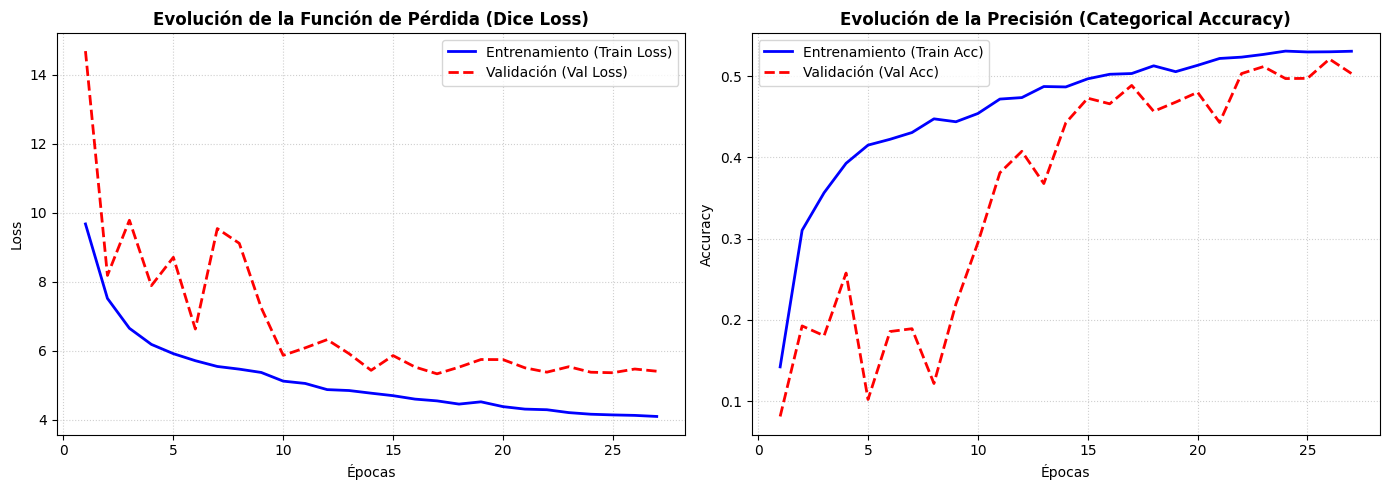

In [24]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño del gráfico con un estilo limpio
plt.figure(figsize=(14, 5))
epochs = range(1, len(history.history['loss']) + 1)

# --- GRÁFICO 1: LOSS (PÉRDIDA) ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b-', label='Entrenamiento (Train Loss)', linewidth=2)
plt.plot(epochs, history.history['val_loss'], 'r--', label='Validación (Val Loss)', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Dice Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# --- GRÁFICO 2: ACCURACY (PRECISIÓN) ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], 'b-', label='Entrenamiento (Train Acc)', linewidth=2)
plt.plot(epochs, history.history['val_accuracy'], 'r--', label='Validación (Val Acc)', linewidth=2)
plt.title('Evolución de la Precisión (Categorical Accuracy)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# 2. Ajustar espacios y guardar la imagen para la memoria del TFG
plt.tight_layout()
plt.savefig('curvas_entrenamiento_tfg.png', dpi=300) # Se guarda automáticamente en alta calidad
plt.show()